In [1]:
import pandas as pd #data handling
import numpy as np #numeric
import matplotlib.pyplot as plt #plots

In [2]:
from google.colab import files
uploaded = files.upload()

Saving 12100168.csv to 12100168.csv


In [3]:
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,REF_DATE,GEO,DGUID,Trade,Basis,Seasonal adjustment,Index,Weighting,North American Product Classification System (NAPCS),UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Total of all merchandise,"Index, 2017=100",373,units,0,v1566912759,1.1.1.1.1.1.1,100.6,NaN,NaN,NaN,1
1,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,"Farm, fishing and intermediate food products [...","Index, 2017=100",373,units,0,v1566912760,1.1.1.1.1.1.2,100.3,NaN,NaN,NaN,1
2,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Farm and fishing products [C111],"Index, 2017=100",373,units,0,v1566912761,1.1.1.1.1.1.3,100.1,NaN,NaN,NaN,1
3,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Live animals [111],"Index, 2017=100",373,units,0,v1566912762,1.1.1.1.1.1.4,109.4,NaN,NaN,NaN,1
4,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Wheat [112],"Index, 2017=100",373,units,0,v1566912763,1.1.1.1.1.1.5,94.0,NaN,NaN,NaN,1


In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
#Making Sure dates aare in order
df['REF_DATE'] = pd.to_datetime(df['REF_DATE'])
df = df.sort_values('REF_DATE')

In [ ]:
df['REF_DATE'].min(), df['REF_DATE'].max()

In [ ]:
df[['REF_DATE']].head()

In [ ]:
df[['REF_DATE']].tail()

In [ ]:
df.columns

In [ ]:
df['North American Product Classification System (NAPCS)'].unique()

In [ ]:
UniCat = df['North American Product Classification System (NAPCS)'].dropna().sort_values().unique()
UniCat

In [ ]:
df['North American Product Classification System (NAPCS)'].value_counts()

In [4]:
catCol = 'North American Product Classification System (NAPCS)'

catTable = pd.DataFrame(
    df[catCol].dropna().unique(),
    columns=['Category']
)

catTable

,Category
0,Total of all merchandise
1,"Farm, fishing and intermediate food products [..."
2,Farm and fishing products [C111]
3,Live animals [111]
4,Wheat [112]
...,...
148,Special transactions trade [C231]
149,Special transactions trade [988]
150,Other balance of payments adjustments [C24]
151,Other balance of payments adjustments [C241]


In [8]:
dfSelected = df[df[catCol].isin(selectedGroups)].copy()

dfSelected[catCol].value_counts()

,count
North American Product Classification System (NAPCS),
Canola (including rapeseed) [113],2568
"Fresh fruit, nuts and vegetables, and pulse crops [114]",2568
"Clothing, footwear and textile products [C222]",2568
"Clothing, footwear and accessories [231]",2568
Furniture and fixtures [C225],2568
Furniture and fixtures [391],2568


In [9]:
selectedGroups = [
    "Furniture and fixtures [C225]","Furniture and fixtures [391]",
    "Clothing, footwear and textile products [C222]", "Clothing, footwear and accessories [231]",
    "Canola (including rapeseed) [113]",
    "Fresh fruit, nuts and vegetables, and pulse crops [114]"
]

dfFiltered = df[df['North American Product Classification System (NAPCS)'].isin(selectedGroups)]

dfFiltered

,REF_DATE,GEO,DGUID,Trade,Basis,Seasonal adjustment,Index,Weighting,North American Product Classification System (NAPCS),UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
5,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Canola (including rapeseed) [113],"Index, 2017=100",373,units,0,v1566912764,1.1.1.1.1.1.6,104.9,NaN,NaN,NaN,1
6,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,"Fresh fruit, nuts and vegetables, and pulse cr...","Index, 2017=100",373,units,0,v1566912765,1.1.1.1.1.1.7,96.3,NaN,NaN,NaN,1
131,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,"Clothing, footwear and textile products [C222]","Index, 2017=100",373,units,0,v1566912890,1.1.1.1.1.1.132,104.2,NaN,NaN,NaN,1
133,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,"Clothing, footwear and accessories [231]","Index, 2017=100",373,units,0,v1566912892,1.1.1.1.1.1.134,105.9,NaN,NaN,NaN,1
141,2017-01,Canada,2021A000011124,Import,Customs,Unadjusted,Price index,Paasche current weighted,Furniture and fixtures [C225],"Index, 2017=100",373,units,0,v1566912900,1.1.1.1.1.1.142,101.5,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388905,2025-11,Canada,2021A000011124,Export,Balance of payments,Seasonally adjusted,Volume index,Laspeyres fixed weighted,"Fresh fruit, nuts and vegetables, and pulse cr...","Index, 2017=100",373,units,0,v1566916248,1.2.2.2.2.2.7,111.0,NaN,NaN,NaN,1
389030,2025-11,Canada,2021A000011124,Export,Balance of payments,Seasonally adjusted,Volume index,Laspeyres fixed weighted,"Clothing, footwear and textile products [C222]","Index, 2017=100",373,units,0,v1566916373,1.2.2.2.2.2.132,93.9,NaN,NaN,NaN,1
389032,2025-11,Canada,2021A000011124,Export,Balance of payments,Seasonally adjusted,Volume index,Laspeyres fixed weighted,"Clothing, footwear and accessories [231]","Index, 2017=100",373,units,0,v1566916375,1.2.2.2.2.2.134,125.4,NaN,NaN,NaN,1
389040,2025-11,Canada,2021A000011124,Export,Balance of payments,Seasonally adjusted,Volume index,Laspeyres fixed weighted,Furniture and fixtures [C225],"Index, 2017=100",373,units,0,v1566916383,1.2.2.2.2.2.142,86.0,NaN,NaN,NaN,1


In [10]:
trade = 'Trade'
index = 'Index'
seasonal = 'Seasonal adjustment'
weight = 'Weighting'
basis = 'Basis'

In [11]:
dfModelBase = dfSelected[
    (dfSelected[trade] == 'Import') &   # Imports only for import demand
    (dfSelected[index] == 'Volume index') & # volume index means quantity(or demand)
    (dfSelected[seasonal] == 'Seasonally adjusted') & #keeping only seasonally adjusted data for now, will revisit this later
    (dfSelected[basis] == 'Customs') #measuring only on basis of customs    #used & to make sure all conditions are true.
].copy()

print("Rows after Import+Volume+SA+Customs:", len(dfModelBase))

Rows after Import+Volume+SA+Customs: 642


In [12]:
dfEda = dfSelected[
    (dfSelected['Trade'] == 'Import') &
    (dfSelected['Index'] == 'Volume index')
].copy()

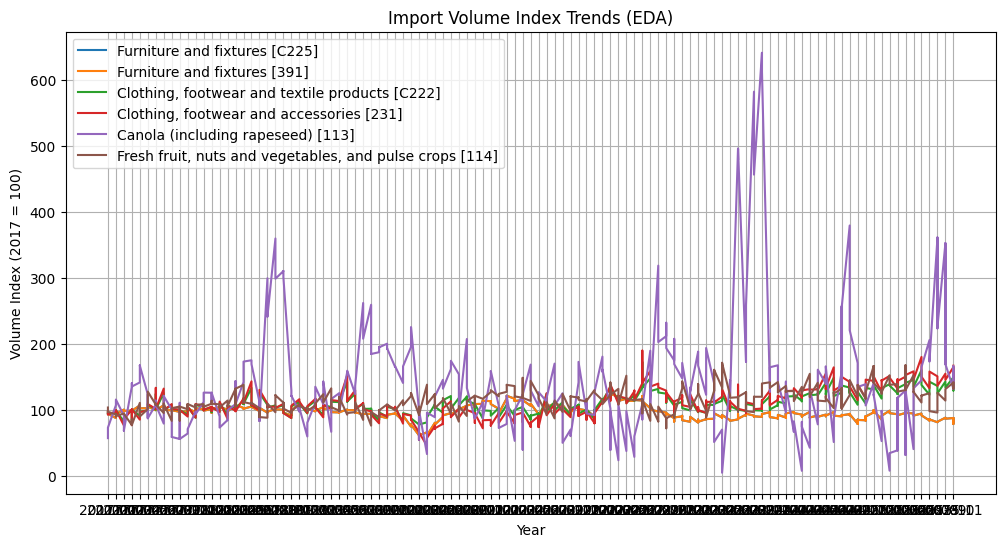

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for group in selectedGroups:
    subsetDf = dfEda[dfEda[catCol] == group].sort_values('REF_DATE')
    plt.plot(subsetDf['REF_DATE'], subsetDf['VALUE'], label=group)

plt.title("Import Volume Index Trends (EDA)")
plt.xlabel("Year")
plt.ylabel("Volume Index (2017 = 100)")
plt.legend()
plt.grid(True)
plt.show()